# Funksjonsanalyse i Python

# Introduksjon
Numerisk funksjonsanalyse

## TODO
* Beskrive forkunnskaper
* Koble til læreplan
* Lage flere oppgaver
  

# Å definere og plotte en funksjon i Python

## Å definere en funksjon og lage en verditabell
I eksempelet under har vi definert en funksjon f som returnerer $4 - x^2$, laget en verditabell for x-verdier og y-verdier:

In [1]:
# importerer nødvendige biblioteker
import numpy as np

# definerer funksjonen vår
def f(x):
    return 4 - x**2

x = np.linspace(-4,4,9)

# her sender vi x-tabellen inn i funksjonen, og lagrer funksjonsverdiene i en y-tabell
y = f(x)

print(x)
print(y)

[-4. -3. -2. -1.  0.  1.  2.  3.  4.]
[-12.  -5.   0.   3.   4.   3.   0.  -5. -12.]


```{tip} Oppgave
Kopier koden til ditt pythonprogram, og prøv å endre på verdien i koden, både på parameterene i linspace() og på selve funksjonsuttrykket og se hva som skjer
```

## Å plotte funksjoner
I programmet nedenfor har jeg lagt til følgende kode nederst i programmet.
```{code-block}Python
plt.plot(x,y, color="red")
plt.axvline(x=0, color="black")
plt.axhline(y=0, color="black")
plt.show()
```

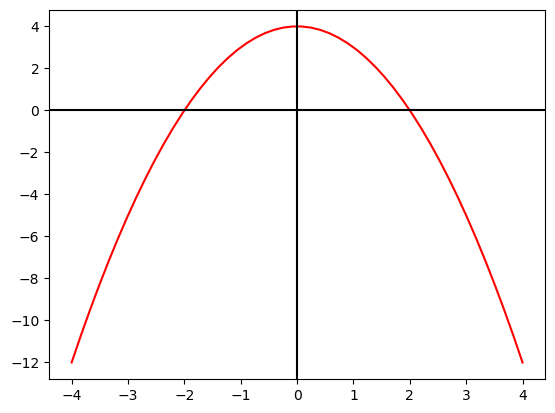

In [3]:
# importerer nødvendige biblioteker
import numpy as np
import matplotlib.pyplot as plt

# definerer funksjonen vår
def f(x):
    return 4 - x**2

x = np.linspace(-4,4,50)

# her sender vi x-tabellen inn i funksjonen, og lagrer funksjonsverdiene i en y-tabell
y = f(x)

plt.plot(x,y, color="red")      # lager et x-y plott med rød farge
plt.axvline(x=0, color="black") # tegner x-aksen i svart
plt.axhline(y=0, color="black") # Tegner y-aksen i svart
plt.show()                      # Viser plottet 

```{tip} Oppgave
Kjør koden på egen maskin. Prøv å endre på forskjellige ting i koden, som feks parametere i linspace() eller selve funksjonen!
```

# Å finne nullpunkter i funksjonen


Det finnes flere metoder for å finne nullpunkter i en funksjon numerisk, vi skal her bare se på den enkleste måten hvor vi rett og slett går igjennom hele verditabellen og finner nullpunktene der y-tabellen har fortegnsskift. For å kunne gjøre dette må vi først se på en metode hvor vi går igjennom tabellen i en for-sløyfe. Denne metoden kalles for *iterasjon*.

## Iterasjon av Arrays

Iterasjon av arrays innebærer å gå igjennom en tabell element for element. Følgende eksempel itererer et array som heter y (tenk y-tabell). Verdien til elementene hentes ut med y[i], der i er elementnummeret som telles opp i for-sløyfa. y.size vil returnere lengden av y-tabellen (her blir det 9, som definert i np.linspace(-4,4,9).

In [8]:
import numpy as np

def f(x):
    return 4 - x**2

x = np.linspace(-4, 4, 9)
y = f(x)
for i in range(y.size):
    print(y[i])

-12.0
-5.0
0.0
3.0
4.0
3.0
0.0
-5.0
-12.0


``` {tip} Oppgaver
1. Hvor er nullpunktene i dette resultatet?
2. Prøv å legge til kode i for-sløyfa slik at du får skrevet ut de tilhørende x-verdiene til nullpunktene?
3. Prøv å endre på antall elementer i np.linspace(-4, 4, 9) fra 9 til 10 og kjør koden på nytt. Hvor er nullpunktene nå?
```

````{hint} Løsningsforslag
:class: dropdown
1. I eksempelet er det lett å se nullpunktene, siden vi faktisk har med de eksakte løsningene i tabellen.
2. Forslag til kode:
```{code} python
import numpy as np

def f(x):
    return 4 - x**2

x = np.linspace(-4, 4, 9)
y = f(x)
for i in range(y.size):
    print(y[i])
    # Her trenger vi en betingelse for å sjekke
    # om vi har et nullpunkt i y-tabellen
    if y[i] == 0:
        # elementene i x og y tilsvarer hverandre, og indeksen i kan
        # nå brukes i x-tabellen for å skrive ut x-verdien
        print("nullpunkt for x = " + str(x[i]))
```
3. Hvis x-tabellen ikke "treffer" nullpunktene så må vi se på fortegnsskifter i tabellen, se neste avsnitt! Test selv om koden over i punkt 2 klarer å finne nullpunktene når lengden på linspace endres fra 9 til 10!
````

I de neste to avsnittene skal vi se på kode som kan finne alle nullpunkter, enten om de ligger i mellom to y-verdier, eller om vi faktisk har et reelt nullpunkt i tabellen. I tillegg er det lagt til kode som plotter funksjonen, og det er nyttig for da kan vi visuelt bekrefte at det finnes nullpunkter i definisjonsområdet vårt.

## Nullpunkter ved fortegnsskift - metode 1
I verditabellen kan vi være heldige, og finne en y-verdi som er akkurat null, men som regel er dette ikke tilfelle. Vi kan imidlertid se på fortegnsskifte: dersom en y-verdi har forskjellig fortegn enn den neste, så har funksjonen krysset x-aksen. Følgende kode bruker np.sign() funksjonen for å finne fortegnet til y-verdien og sjekker for fortegnsskift.

Dersom vi har fortegnsskift må nullpunktet ligge MELLOM de tilhørende x-verdiene, derfor tar vi gjennomsnittet av disse to for å få et mer nøyaktig resultat. Dersom vi er så heldige at vi har et eksakt nullpunkt i tabellsettet, så får vi nødvendigvis ikke fortegnsskift derfor må vi teste for dette også i elif-blokken under.

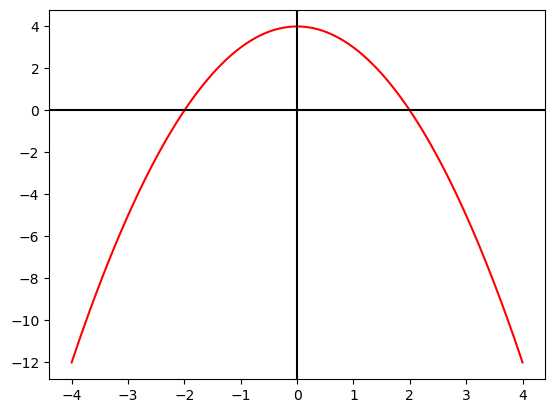

nullpunkt x = -2.02020202020202
nullpunkt x = 2.0202020202020208


In [2]:
# Importerer biblioteker
import numpy as np
import matplotlib.pyplot as plt
# Definerer funksjoner
def f(x):
    return 4 - x**2

# Antall elementer i x og y-tabellene
N = 100
# Lager x-tabell
x = np.linspace(-4,4,N)
# Lager y-tabell med tilhørende funksjonsverdier
y = f(x)
# Plotter grafen (ser om det faktisk finnes nullpkt)
plt.plot(x,y, color="red")
plt.axvline(x=0, color="black")
plt.axhline(y=0, color="black")
plt.show()
# Itererer y-tabellen for å finne fortegnsskift eller 0
for i in range(N-1):
    if np.sign(y[i]) != np.sign(y[i+1]):
        # Tar gjennomsnittet av x[i] og x[i+1]
        nullp = (x[i]+x[i+1])/2
        print("nullpunkt x = " + str(nullp))
    # sjekker også etter reelt nullpunkt
    elif y[i] == 0:
        print("nullpunkt x = " + str(x[i]))

## Nullpunkter ved fortegnsskift - metode 2 (snedig)
Man trenger ikke bruke sign(), men vi kan bruke fortegnsreglene for produkter til å lage en enklere test. Dersom y og neste y har samme fortegn, så vil produktet alltid være positivt. Dersom vi har et fortegnsskift mellom y og neste y, så vil produktet være negativt. Koden under viser hvordan dette kan gjøres:

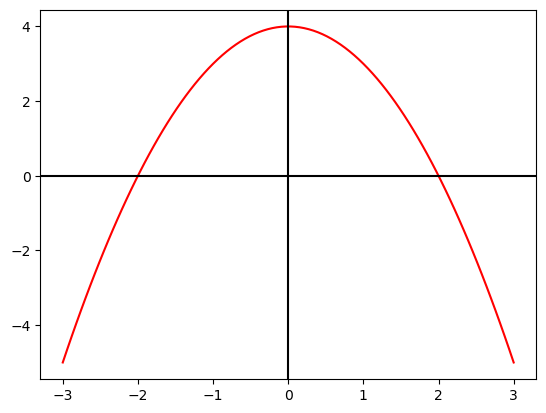

nullpunkt x = -2.0
nullpunkt x = 2.0


In [1]:
# Importerer biblioteker
import numpy as np
import matplotlib.pyplot as plt
# Definerer funksjoner
def f(x):
    return 4 - x**2

# Antall elementer i x og y-tabellene
N = 100
# Lager x-tabell
x = np.linspace(-3,3,N)
# Lager y-tabell med tilhørende funksjonsverdier
y = f(x)
# Plotter grafen (ser om det faktisk finnes nullpkt)
plt.plot(x,y, color="red")
plt.axvline(x=0, color="black")
plt.axhline(y=0, color="black")
plt.show()
# Itererer y-tabellen for å finne fortegnsskift eller 0
for i in range(N-1):
    if y[i] * y[i+1] < 0:
        # Tar gjennomsnittet av x[i] og x[i+1]
        nullp = (x[i]+x[i+1])/2
        print("nullpunkt x = " + str(nullp))
    # sjekker også etter reelt nullpunkt
    elif y[i] == 0:
        print("nullpunkt x = " + str(x[i]))

Nå har vi to versjoner av et verktøy som kan finne nullpunkter på alle funksjoner, i definisjonsområdet til x. 

````{tip} Oppgave
Nå kan du prøve ut andre funksjonsuttrykk, bare husk på at du må sjekke plottet og eventuelt justere definsjonsområdet i linspace() slik at nullpunktene faktisk eksisterer i datasettet.
Prøv for eksempel $ f(x)=cos⁡(x)+x $
Dette er en såkalt transcendental likning, som ikke er mulig å løse analytisk (ved regning!). Koden for å bruke cosinus i Python er:
```{code-block}Python
y = np.cos(x) + x
```
````

# Finne ekstremalpunkter i funksjonen
Vi kan bruke samme metode for å finne ekstremalpunkter i funksjonen som vi gjorde for nullpunkter, men betingelsen er forskjellig. For nullpunkter undersøkte vi fortegnsskift, for ekstremalverdier må vi undersøke for topp- eller bunnpunkter. Et eksempel for kode kan være:

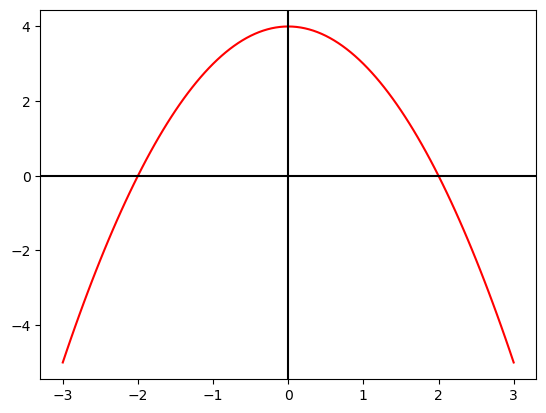

toppunkt x = 0.0, y = 4.0


In [11]:
# Importerer biblioteker
import numpy as np
import matplotlib.pyplot as plt

# Definerer funksjoner
def f(x):
    return 4 - x**2

# Antall elementer i x og y-tabellene
N = 109
# Lager x-tabell
x = np.linspace(-3,3,N)
# Lager y-tabell med tilhørende funksjonsverdier
y = f(x)
# Plotter grafen (ser om det faktisk finnes nullpkt)
plt.plot(x,y, color="red")
plt.axvline(x=0, color="black")
plt.axhline(y=0, color="black")
plt.show()
# Itererer y-tabellen for å finne topp eller bunnpunkter
for i in range(N-2):
    # sjekker for toppunkt
    if y[i] < y[i+1] and y[i+1] > y[i+2] :
        print("toppunkt x = " + str(x[i+1]) + ", y = " + str(y[i+1]))
    elif y[i] > y[i+1] and y[i+1] < y[i+2]:
        print("bunnpunkt x = " + str(x[i+1]) + ", y = " + str(y[i+1]))

````{tip} Oppgaver
1. Prøv å endre funksjonen til en annen andregradsfunksjon, en med positivt fortegn for x, feks $f(x)=x^2-4$, og sjekk at programmet også skriver ut bunnpunkter!
2. Prøv å endre antall punkter i tabellen til N=100. Hva skjer? Hvordan kan vi fikse dette problemet?
````

````{hint} Løsning oppgave 2
:class: dropdown
Hvis man endrer N til 100 så er vil ikke testen:
```{code} python
if y[i] < y[i+1] and y[i+1] > y[i+2]
```
finne toppunktet, fordi det er to x-verdiene som ligger rundt symmetrilinjen ha samme verdi. Vi må legge til en ekstra test, både for topp- og bunnpunkt. Hvordan må vi endre if-testene? Løsningsforslag finnes i boksen nedenfor:
````

````{hint} Løsning på problemet!!
:class: dropdown
I koden nedenfor er det lagt til en ekstra test for topp- og bunnpunkt. Hvordan fungerer de? Hvorfor regnes gjennomsnittet for x_verdien som vi har funnet for ekstremalpunktet? Legg også merke til at vi må bruke funksjonen f(x) for å finne toppunktet, for denne verdien finnes ikke i Arrayet y.
```{code} python
# Importerer biblioteker
import numpy as np
import matplotlib.pyplot as plt
# Definerer funksjoner
def f(x):
    return 4 - x**2

# Antall elementer i x og y-tabellene
N = 100 #NB
# Lager x-tabell
x = np.linspace(-3,3,N)
# Lager y-tabell med tilhørende funksjonsverdier
y = f(x)
# Plotter grafen (ser om det faktisk finnes nullpkt)
plt.plot(x,y, color="red")
plt.axvline(x=0, color="black")
plt.axhline(y=0, color="black")
plt.show()
# Itererer y-tabellen for å finne topp eller bunnpunkter
for i in range(N-2):
    # sjekker for toppunkt
    if y[i] < y[i+1] and y[i+1] > y[i+2]:
        print("toppunkt x = " + str(x[i+1]) + ", y = " + str(y[i+1]))
    elif y[i] == y[i+1] and y[i+1] > y[i+2]:
        x_snitt = (x[i]+x[i+1])/2
        print("toppunkt x = " + str(x_snitt) + ", y = " + str(f(x_snitt)))
    # sjekker for bunnpunkt
    elif y[i] > y[i+1] and y[i+1] < y[i+2]:
        print("bunnpunkt x = " + str(x[i+1]) + ", y = " + str(y[i+1]))
    elif y[i] == y[i+1] and y[i+1] < y[i+2]:
        x_snitt = (x[i]+x[i+1])/2
        print("bunnpunkt x = " + str(x_snitt) + ", y = " + str(f(x_snitt)))
```
````

# Numerisk derivasjon (momentan vekstfart)

Med utgangspunkt i definisjonen for den deriverte, her er en Python-funksjon som finner den deriverte i ett valgt punkt på andregradsfunksjonen

## Å finne vekstfarten i ett punkt

In [4]:
def f(x):
    return 4 - x**2

def deriverte(x,delta_x):
    return (f(x+delta_x)-f(x))/delta_x

x = 0
dx = 0.01

print("Den deriverte i punkt (" + str(x) + ", " + str(f(x)) + ")")
print("er: " + str(deriverte(x, dx)))

Den deriverte i punkt (0, 4)
er: -0.010000000000021103


````{tip}
Funksjonen $f(x)=4-x^2$ er symmetrisk om y-aksen (som dere så ovenfor) og har toppunkt i (0,4), dvs at den deriverte i punktet (0,4) skal bli null. Hva sier Python? Hvorfor?
Prøv å gjøre dx enda mindre, for eksempel 0,01, 0,001 osv. Hva skjer?
Prøv med andre verdier for x, eller også å skrive inn andre funksjoner, og sammenlign med for eksempel Geogebra, eller regn fasit for hånd.
````

## Numeriske begrensinger
I matematikk bruker vi grenseverdien, når delta_x går mot 0, for å finne den deriverte analytisk. Det skulle da også være rimelig at det samme gjaldt når man regnet den deriverte numerisk med en datamaskin. Dette programmet analyserer hva forskjellen mellom den beregnede deriverte og den numeriske tilnærmingen blir for punktet (1, f(1)). Hva gjør programmet?

````{code} python
def f(x):
    return x**2 - 2

# analytisk derivert
def analytisk_derivert(x):
    return 2*x

def numerisk_derivert(f, x, delta_x):
    fder = (f(x + delta_x)-f(x))/delta_x
    return fder

delta_x = []

for i in range(1,16):
    dx = 10**(-i)
    delta_x.append(dx)
    numder = numerisk_derivert(f, 1, dx)
    ander = analytisk_derivert(1)
    feil = ander - numder
    print("Delta_x =", dx, " avvik:", feil)
````

````{tip}
Kjør koden. Hva skjer med den numeriske tilnærmingen når den delta_x blir veldig liten? Hva er sweetspot for dx?
````

## Plotting av den deriverte
Dersom man har en verditabell for x-verdier, kan man finne en verditabell for den deriverte også – dette er nødvendig dersom man vil plotte den deriverte: Kjør følgende kode, og prøv å se hva den gjør

````{code} python
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return 4 - x**2

def fderivert(x, delta_x):
    fder = (f(x + delta_x)-f(x))/delta_x
    return fder

dx = 0.00000001

x = np.linspace(-3,3,100)
y = f(x)
derivert = fderivert(x, dx)


plt.plot(x, y, color="red")
plt.plot(x, derivert, color = "blue")

plt.axvline(x=0, color="black")
plt.axhline(y=0, color="black")
plt.show()
````

````{tip}
Eksperimenter med andre funksjoner, feks

$f(x)=x^2-x+12$

$f(x)=-\frac{1}{3}x^3-2x^2+x-1$
````